# L14d: MIMO S4 emulator for fed-batch CHO bioreactor prediction
In this lab we use the block-diagonal HiPPO-LegS multi-input multi-output (MIMO) structured state space model from the L14c lecture to learn the full 7-state trajectory of a fed-batch Chinese Hamster Ovary (CHO) bioreactor producing a monoclonal antibody. This is the same forecasting problem as the L12d LSTM lab, but the recurrent model is now a frozen MIMO S4 whose only trainable component is the dense readout $\bar{\mathbf{C}}$, fit by a single closed-form ridge solve.

__Problem statement.__ Simulate 50 fed-batch runs at different glucose-triggered feed policies and hold out 10. On the remaining 40, fit the MIMO S4 readout by teacher-forced next-state regression; inputs at each step are the seven-state vector, the three-number feed policy, a feed-on bit, and the feed-rate channel $f_t \cdot F_\text{max}$. At evaluation, roll the emulator autoregressively on each held-out condition and compare to the ground-truth ODE.

The rest of the notebook works toward this goal in three tasks: generating the simulated dataset, building and fitting the MIMO S4 emulator, and evaluating it autoregressively against the ground-truth ODE solution with a direct comparison to the L12d LSTM numbers.

> __Learning Objectives:__
>
> By the end of this lab, you should be able to:
>
> * __Frame multi-state ODE forecasting as a MIMO S4 regression:__ Map the bioreactor state, the feed policy, and the pump schedule onto the input and output channels of a MIMO structured state-space model. Use teacher-forced next-state targets to turn the problem into a closed-form ridge fit of the readout.
> * __Fit a MIMO S4 readout across many trajectories in one linear system:__ Roll a frozen HiPPO-LegS SSM forward from a zero initial hidden state on each training trajectory. Fit the dense readout jointly across all trajectories with the multi-trajectory ridge helper.
> * __Evaluate autoregressively on held-out feed policies:__ Roll the trained emulator forward from the true initial state while supplying the known feed schedule as an exogenous signal. Score each held-out condition by mean-squared error, final antibody titer, and maximum biomass against the ground-truth ODE solution.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes local source files in `src/`. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

* [`src/Types.jl`](src/Types.jl) defines `MyMimoLegSHippoModel` and `MyFedBatchCHOParameters`.
* [`src/Parameters.jl`](src/Parameters.jl) defines `build_default_parameters` for the Xing et al. 2010 CHO kinetics.
* [`src/Kinetics.jl`](src/Kinetics.jl) defines the growth, product, and substrate-uptake rate laws.
* [`src/MassBalances.jl`](src/MassBalances.jl) defines the ODE right-hand side `rhs!` and the glucose-triggered feed callbacks.
* [`src/Simulation.jl`](src/Simulation.jl) defines `simulate_fedbatch`, `generate_cho_dataset`, `normalize_minmax_perstate`, `apply_minmax_perstate`, `denormalize_minmax`, `add_measurement_noise`, and `compute_feed_on`.
* [`src/Compute.jl`](src/Compute.jl) defines `build_legS_matrices_mimo`, `discretize`, `build`, `rollout`, `solve`, `fit_C!`, `fit_C_multi!`, `autoregressive_rollout_feedon`, and `predict`.
* [`src/Files.jl`](src/Files.jl) defines `save_model_checkpoint` and `load_model_checkpoint`.

In [1]:
include("Include.jl"); # load packages, src/ files, set random seed

  Activating project at `~/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14d`


### Constants
We'll use several constants throughout this lab. We define them here for easy reference and modification. See the comment next to each constant for an explanation of its purpose and units.

In [ ]:
# --- simulation / dataset constants -----------------------------------------
N_CONDITIONS  = 50                              # total number of fed-batch runs simulated
N_TRAIN       = 40                              # number used to fit the readout (80/20 split)
TSPAN         = (0.0, 336.0)                    # simulation window in hours (14 days)
SAVEAT        = 1.0                             # sample rate (1 hour)
INITIAL_STATE = [10.0, 0.3, 25.0, 8.0, 0.0, 0.0, 0.0]  # V, X, Glc, Gln, P, Lac, Amm

# --- feed-policy sampling ranges --------------------------------------------
F_MAX_RANGE   = (0.01, 0.5)                     # maximum feed rate in L/h
GLC_MIN_RANGE = (1.0, 5.0)                      # glucose threshold to turn feed ON (mM)
GLC_MAX_RANGE = (10.0, 30.0)                    # glucose threshold to turn feed OFF (mM)

# --- measurement noise ------------------------------------------------------
# Per-state relative Gaussian noise: σ_j = σ_rel * (state_max_j - state_min_j)
# fit on the training set. Train and test noise levels are independent:
#   TRAIN_NOISE_σ_REL — applied to the 40 training trajectories (drives the fit).
#   EVAL_NOISE_σ_REL  — applied to the 10 held-out test trajectories (rollout
#                       initial condition and per-sample observations).
# Only the model cache key depends on TRAIN_NOISE_σ_REL, so you can fit once at
# σ_train = 0 and sweep σ_eval at rollout time without refitting — an out-of-
# distribution test where the readout never saw noise.
TRAIN_NOISE_σ_REL = 0.0
EVAL_NOISE_σ_REL  = 0.0

# --- MIMO S4 constants ------------------------------------------------------
N_STATES      = 7                               # bioreactor state dimension (V, X, Glc, Gln, P, Lac, Amm)
N_COND        = 3                               # feed-policy conditioning dimension (F_max, Glc_min, Glc_max)
GLC_IDX       = 3                               # index of glucose (Glc) in the 7-state vector
F_IDX         = 1                               # index of F_max in the 3-component conditioning vector
D_IN          = N_STATES + N_COND + 2           # MIMO S4 input width (7 state + 3 cond + feed_on + feed_on*F_max)
D_OUT         = N_STATES                        # MIMO S4 output width (predict all seven states)
H_PER_CHANNEL = 8                               # per-channel LegS order; total hidden size H = H_PER_CHANNEL * D_IN
RIDGE_λ       = 1.0e-4                          # ridge regularization on the readout fit
SEED          = 42                              # RNG seed for reproducibility

# --- persistence ------------------------------------------------------------
# Cache tag depends only on TRAIN_NOISE_σ_REL. The fitted readout is a function
# of the training noise, not the eval noise, so changing EVAL_NOISE_σ_REL alone
# reuses the cached model instead of triggering a refit.
MODEL_PATH    = joinpath(_PATH_TO_DATA,
    "mimo-s4-cho-h$(H_PER_CHANNEL)-feedrate-sigma$(round(TRAIN_NOISE_σ_REL; digits = 3)).jld2")

___

## Task 1: Simulate the fed-batch CHO dataset
In this task, we simulate `N_CONDITIONS` fed-batch bioreactor runs, each at a randomly sampled glucose-triggered feed policy $(F_\text{max}, \text{Glc}_\text{min}, \text{Glc}_\text{max})$, then split the runs 80/20 into training and test sets, add per-state measurement noise to the observed trajectories to emulate sensor error, and normalize each state to the $[0, 1]$ range using the training-set bounds.

Let's take a look at the details of each step:
* __Bioreactor model.__ [The `simulate_fedbatch(...)` function](src/Simulation.jl) integrates a seven-state ODE, $(V, X, \text{Glc}, \text{Gln}, P, \text{Lac}, \text{Amm})$, with hysteresis feeding: the pump turns on below $\text{Glc}_\text{min}$ and off above $\text{Glc}_\text{max}$ at rate $F_\text{max}$.
* __Measurement noise.__ The ODE is ground truth; [the `add_measurement_noise(...)` function](src/Simulation.jl) adds iid Gaussian noise with per-state $\sigma_j = \sigma_\text{rel} \cdot (\text{state\_max}_j - \text{state\_min}_j)$ fit on the training set. Train and test noise levels are independent: the 40 training runs use `TRAIN_NOISE_σ_REL`, the 10 held-out runs use `EVAL_NOISE_σ_REL`, and the two draws come from independent RNG streams so changing one σ does not perturb the other. We keep `state_arrays_true` (clean, used only for scoring and the feed-on signal) and `state_arrays` (noisy, fed to the model); setting both σ's to 0 makes them identical. Because the model cache key depends only on `TRAIN_NOISE_σ_REL`, you can fit at σ_train = 0 and sweep σ_eval at rollout time without refitting — an out-of-distribution test where the readout never saw noise.
* __Normalization.__ State magnitudes vary by orders, so [the `normalize_minmax_perstate(...)` function](src/Simulation.jl) fits per-state min/max on the noisy training observations, rescales every trajectory to $[0, 1]$, and applies the same scaler to the clean arrays via [the `apply_minmax_perstate(...)` function](src/Simulation.jl) so normalized MSE is measured on a common axis. The feed-policy vector is normalized the same way.

The code block below populates the following named outputs:

* `time_vector::Vector{Float64}` — length-337 common time grid in hours (0 to 336 at 1-hour spacing).
* `state_arrays_true::Vector{Matrix{Float64}}` — 50 clean ODE trajectories, each a $337 \times 7$ matrix in natural units.
* `state_arrays::Vector{Matrix{Float64}}` — same shape as `state_arrays_true`, with per-state Gaussian noise at `TRAIN_NOISE_σ_REL` for training indices and `EVAL_NOISE_σ_REL` for test indices (this is what the model sees).
* `state_norm_true::Vector{Matrix{Float64}}` — clean trajectories rescaled to the $[0, 1]$ range using the training-set scaler, used only for normalized-MSE scoring.
* `state_norm::Vector{Matrix{Float64}}` — noisy trajectories rescaled with the same scaler, used to fit the readout and to seed each rollout.
* `cond_norm::Vector{Vector{Float64}}` — 50 entries, each a length-3 normalized feed-policy vector $(F_\text{max}, \text{Glc}_\text{min}, \text{Glc}_\text{max})$.
* `train_idx::Vector{Int}`, `test_idx::Vector{Int}` — 40 training indices and 10 held-out test indices from the 80/20 split.
* `state_mins::Vector{Float64}`, `state_maxs::Vector{Float64}` — length-7 per-state min and max bounds used by the scaler, fit on noisy training observations only.

In [ ]:
(; time_vector, state_arrays_true, state_arrays, cond_list,
   state_norm_true, state_norm, cond_norm,
   train_idx, test_idx, state_mins, state_maxs) = let

    # sample N_CONDITIONS random feed policies from the three uniform ranges
    Random.seed!(SEED)
    conds = [(rand(Distributions.Uniform(F_MAX_RANGE...)),
              rand(Distributions.Uniform(GLC_MIN_RANGE...)),
              rand(Distributions.Uniform(GLC_MAX_RANGE...))) for _ in 1:N_CONDITIONS]
    @info "sampled feed policies" n=length(conds)

    # simulate every condition on a common time grid (this is the ground truth)
    (tv, sa_true, cl) = generate_cho_dataset(conds; u0 = INITIAL_STATE, tspan = TSPAN, saveat = SAVEAT)
    @info "simulations complete" n_timepoints=length(tv) n_states=size(sa_true[1], 2) n_conditions=length(sa_true)

    # reproducible 80/20 train/test split.
    Random.seed!(SEED)
    perm = shuffle(1:N_CONDITIONS)
    tr_idx = perm[1:N_TRAIN]
    te_idx = perm[(N_TRAIN + 1):end]

    # Add per-state relative measurement noise. Training trajectories get
    # TRAIN_NOISE_σ_REL; test trajectories get EVAL_NOISE_σ_REL. Independent
    # RNG streams (SEED+1 for train, SEED+2 for test) so changing one σ does
    # not perturb the other draw. sa_true = clean ODE ground truth;
    # sa = what the model actually sees. Both σ's at 0.0 reproduces the
    # clean baseline exactly.
    sa_train_noisy = add_measurement_noise(sa_true, TRAIN_NOISE_σ_REL, tr_idx; rng = MersenneTwister(SEED + 1))
    sa_eval_noisy  = add_measurement_noise(sa_true, EVAL_NOISE_σ_REL,  tr_idx; rng = MersenneTwister(SEED + 2))
    sa = [i ∈ tr_idx ? sa_train_noisy[i] : sa_eval_noisy[i] for i in 1:N_CONDITIONS]

    # Per-state min-max normalization. Bounds are fit on the NOISY training
    # observations (the practitioner does not have the clean trajectory), then
    # the same scaler is applied to both noisy and clean arrays so normalized-
    # scale scoring compares on a single [0, 1] axis.
    (sn,      mins, maxs) = normalize_minmax_perstate(sa, tr_idx)
    sn_true              = apply_minmax_perstate(sa_true, mins, maxs)

    # per-component min-max normalization of the feed-policy conditioning
    cond_mat = [cl[i][j] for i in 1:N_CONDITIONS, j in 1:N_COND]
    c_mins = [minimum(cond_mat[tr_idx, j]) for j in 1:N_COND]
    c_maxs = [maximum(cond_mat[tr_idx, j]) for j in 1:N_COND]
    cn = [Float64[(cl[i][j] - c_mins[j]) / (c_maxs[j] - c_mins[j] + 1.0e-12) for j in 1:N_COND] for i in 1:N_CONDITIONS]

    @info "dataset prepared" n_train=length(tr_idx) n_test=length(te_idx) σ_train=TRAIN_NOISE_σ_REL σ_eval=EVAL_NOISE_σ_REL state_mins=round.(mins, digits=2) state_maxs=round.(maxs, digits=2)
    (time_vector = tv,
     state_arrays_true = sa_true, state_arrays = sa, cond_list = cl,
     state_norm_true = sn_true, state_norm = sn, cond_norm = cn,
     train_idx   = tr_idx, test_idx = te_idx,
     state_mins  = mins, state_maxs = maxs)
end;

### Representative training trajectories
A quick sanity check: plot four training trajectories for the four most interesting states (biomass X, glucose Glc, product P, lactate Lac). Every curve lives on its normalized $[0, 1]$ axis so the relative shapes are directly comparable across states and conditions.

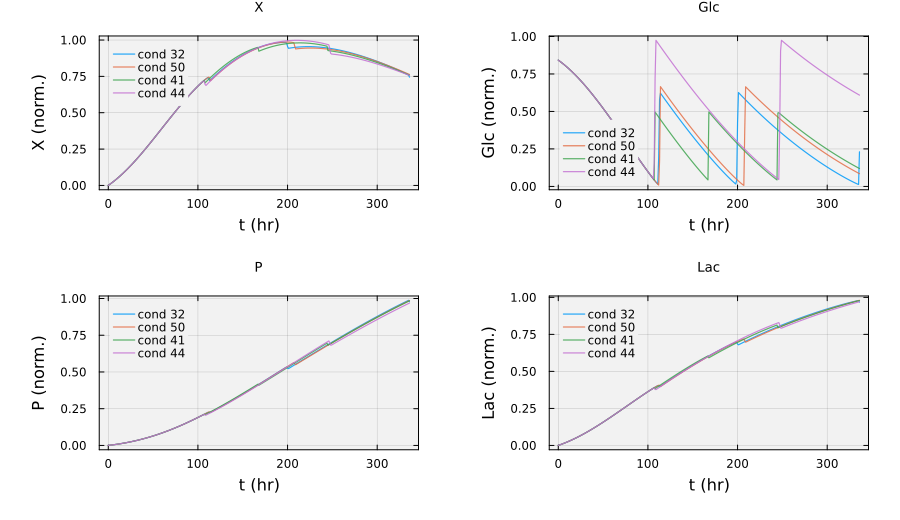

In [4]:
let
    state_labels = ["V", "X", "Glc", "Gln", "P", "Lac", "Amm"]
    show_states  = [2, 3, 5, 6]                 # X, Glc, P, Lac
    show_conds   = train_idx[1:4]               # first four training conditions
    plots_grid   = Any[]
    for s in show_states
        p = plot(; xlabel = "t (hr)", ylabel = "$(state_labels[s]) (norm.)",
                   bg = "gray95", background_color_outside = "white",
                   framestyle = :box, fg_legend = :transparent,
                   title = state_labels[s], titlefont = font(9))
        for c in show_conds
            plot!(p, time_vector, state_norm[c][:, s];
                  label = "cond $(c)", lw = 1.2, alpha = 0.85)
        end
        push!(plots_grid, p)
    end
    plot(plots_grid...; layout = (2, 2), size = (900, 520),
         left_margin = 10Plots.mm, bottom_margin = 8Plots.mm,
         right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about
* __Why use $(F_\text{max}, \text{Glc}_\text{min}, \text{Glc}_\text{max})$ as conditioning?__ Different feed policies give visibly different trajectories even at the same initial state — look at the spread across conditions in the four-state grid above. What does that spread imply about the minimum conditioning a next-state predictor needs in order to pick the right trajectory, and why is the feed-policy triple a natural choice? Tie your answer to which of the visible shapes (smooth decays vs. feed-driven oscillations) are controlled by the threshold pair versus the feed-rate magnitude.

___

## Task 2: Build the MIMO S4 emulator and fit the readout
In this task, we build the frozen MIMO S4 emulator and fit its dense readout $\bar{\mathbf{C}}$ with one closed-form ridge solve.

__MIMO S4 setup and fit.__ The model is a frozen MIMO S4 whose only trainable object is the dense readout $\bar{\mathbf{C}}$, fit in one closed-form ridge solve.
* __Shape:__ [the `MyMimoLegSHippoModel` type](src/Types.jl) with `d_in = 12` (seven-state + three-component feed policy + feed-on bit + feed-rate channel $f_t \cdot F_\text{max}^\text{norm}$), `d_out = 7`, hidden size $H = h \cdot d_\text{in}$ at $h = 8$, $\Delta t = 1$.
* __Operator-known inputs:__ the feed-on bit comes from [the `compute_feed_on(...)` function](src/Simulation.jl) because the pump log is a known operator signal, and the 12th channel precomputes the product $f_t \cdot F_\text{max}^\text{norm}$ because a linear readout cannot multiply two inputs on its own.
* __Closed-form fit:__ [the `fit_C_multi!(...)` function](src/Compute.jl) solves one $H \times H$ ridge system with row $t$ of $\mathbf{U}_i$ equal to $[\mathbf{x}_t^\text{norm}; \mathbf{c}_i^\text{norm}; f_{i,t}; f_{i,t} F_{\text{max},i}^\text{norm}]$ and row $t$ of $\mathbf{Y}_i$ equal to $\mathbf{x}_{t+1}^\text{norm}$.

The code block below stores the trained emulator as `ssm` and caches it at `MODEL_PATH` so reruns skip the fit.

In [5]:
ssm = let
    if isfile(MODEL_PATH)
        m = load_model_checkpoint(MODEL_PATH)
        @info "loaded cached model" path=MODEL_PATH H=(m.h * m.d_in) h=m.h d_in=m.d_in d_out=m.d_out
        m
    else
        # build the frozen SSM feature extractor
        m = build(MyMimoLegSHippoModel; h = H_PER_CHANNEL, d_in = D_IN, d_out = D_OUT, Δt = 1.0)
        @info "SSM built" h=m.h d_in=m.d_in d_out=m.d_out H=(m.h * m.d_in)

        # build the (U_i, Y_i) teacher-forced pairs for every training trajectory
        U_list = Matrix{Float64}[]
        Y_list = Matrix{Float64}[]
        for i in train_idx
            X = state_norm[i]                   # (T × N_STATES) NOISY normalized trajectory
            c = cond_norm[i]                    # (N_COND,) normalized feed-policy conditioning

            # Reconstruct the feed-pump on/off schedule from the CLEAN glucose
            # trajectory: in a real plant the operator reads the pump log, so
            # fon is a known operator signal and is not corrupted by sensor noise.
            glc_true = state_arrays_true[i][:, GLC_IDX]
            fon      = compute_feed_on(glc_true)
            frate    = fon .* c[F_IDX]          # instantaneous normalized feed rate

            T = size(X, 1)
            U = zeros(Float64, T - 1, D_IN)
            Y = zeros(Float64, T - 1, D_OUT)
            for t in 1:(T - 1)
                U[t, 1:N_STATES]                         = X[t, :]
                U[t, (N_STATES + 1):(N_STATES + N_COND)] = c
                U[t, N_STATES + N_COND + 1]              = fon[t]
                U[t, N_STATES + N_COND + 2]              = frate[t]
                Y[t, :]                                  = X[t + 1, :]
            end
            push!(U_list, U)
            push!(Y_list, Y)
        end
        @info "training pairs built" n_trajectories=length(U_list) rows_per_traj=size(U_list[1], 1) d_in=size(U_list[1], 2)

        # closed-form multi-trajectory ridge fit of the readout C
        @info "fitting readout C across all training trajectories..."
        t0 = time()
        fit_C_multi!(m, U_list, Y_list; λ = RIDGE_λ)
        @info "fit complete" elapsed_seconds=round(time() - t0, digits = 2)

        save_model_checkpoint(MODEL_PATH, m)
        @info "saved checkpoint" path=MODEL_PATH bytes=filesize(MODEL_PATH)
        m
    end
end;

┌ Info: SSM built
│   h = 8
│   d_in = 12
│   d_out = 7
│   H = 96
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14d/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sZmlsZQ==.jl:9
┌ Info: training pairs built
│   n_trajectories = 40
│   rows_per_traj = 336
│   d_in = 12
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14d/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sZmlsZQ==.jl:38
┌ Info: fitting readout C across all training trajectories...
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14d/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sZmlsZQ==.jl:41
┌ Info: fit complete
│   elapsed_seconds = 0.34
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14d/jl_notebook_ce

### In-sample autoregressive fit on a representative training trajectory
Before evaluating on held-out runs, let's visually confirm the fit on one training trajectory. We roll the trained emulator autoregressively from the true initial state and the trajectory's own feed policy, then overlay the resulting seven-state trajectory on top of the ground-truth ODE curve.

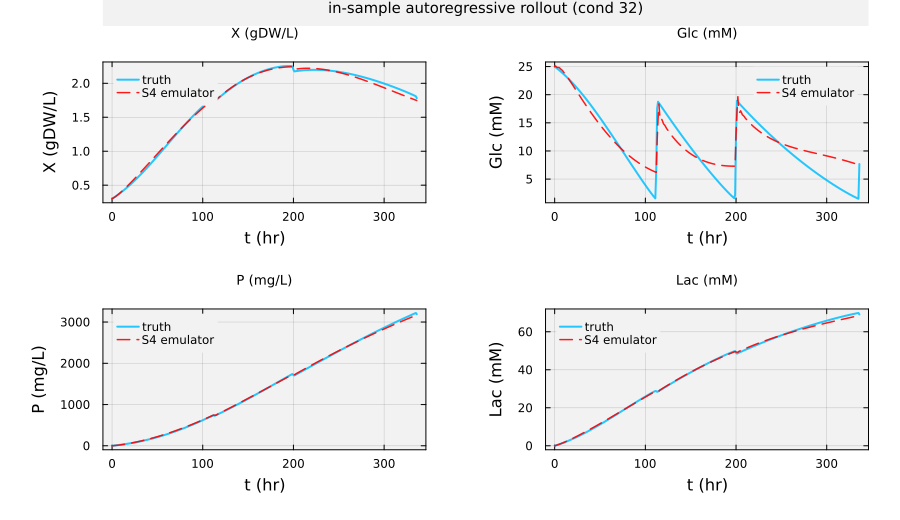

In [6]:
let
    i      = train_idx[1]

    # Initial hidden-state observation for the rollout is the noisy first sample
    # (what the practitioner actually measures on day 0). With σ = 0 this equals
    # the clean initial condition exactly.
    x0     = state_norm[i][1, :]

    # Reconstruct the feed-pump schedule from the CLEAN ODE glucose trajectory
    # (the operator's pump log) and pass it in as a known exogenous input.
    fon = compute_feed_on(state_arrays_true[i][:, GLC_IDX])

    preds   = autoregressive_rollout_feedon(ssm, x0, cond_norm[i], fon)
    preds_d = denormalize_minmax(preds, state_mins, state_maxs)
    truth_d = state_arrays_true[i]                 # score against CLEAN ground truth

    state_labels = ["V (L)", "X (gDW/L)", "Glc (mM)", "Gln (mM)", "P (mg/L)", "Lac (mM)", "Amm (mM)"]
    show_states  = [2, 3, 5, 6]
    plots_grid   = Any[]
    for s in show_states
        p = plot(time_vector, truth_d[:, s];
                 label = "truth", lw = 2, c = :deepskyblue, alpha = 0.85,
                 bg = "gray95", background_color_outside = "white",
                 framestyle = :box, fg_legend = :transparent,
                 xlabel = "t (hr)", ylabel = state_labels[s],
                 title = state_labels[s], titlefont = font(9))
        plot!(p, time_vector, preds_d[:, s];
              label = "S4 emulator", lw = 1.5, c = :red, alpha = 0.9, ls = :dash)
        push!(plots_grid, p)
    end
    plot(plots_grid...; layout = (2, 2), size = (900, 520),
         left_margin = 10Plots.mm, bottom_margin = 8Plots.mm,
         right_margin = 6Plots.mm, top_margin = 4Plots.mm,
         plot_title = "in-sample autoregressive rollout (cond $(i))", plot_titlefont = font(10))
end

### Things to think about
* __What does closed-form ridge trade against SGD?__ [The `fit_C_multi!(...)` function](src/Compute.jl) solves one $H \times H$ linear system in a few hundred milliseconds; the L12d LSTM lab trained the analogous next-state predictor with 500 SGD epochs. What does each approach spend (expressiveness, data efficiency, wall-clock time, hyperparameter count), and what does each get back in return? Explain why the SSM's frozen dynamics — the fact that $\mathbf{x}_t$ is determined entirely by the analytic HiPPO-LegS matrices — are what make the ridge path available at all.

___

## Task 3: Evaluate autoregressively on held-out feed policies
In this task, we roll the trained emulator autoregressively on each of the 10 held-out test conditions, starting from the true initial state and letting the model feed its own predictions back in at every step. We then score each rollout against the ground-truth ODE trajectory and report per-condition mean-squared error, final antibody titer, and maximum biomass.

* **Autoregressive rollout.** [The `autoregressive_rollout_feedon(...)` function](src/Compute.jl) advances the SSM hidden state step by step, overwriting the input with $[\hat{\mathbf{x}}_t; \mathbf{c}_i; f_{i,t}; f_{i,t} \cdot F_{\text{max},i}^\text{norm}]$: the model's own previous prediction, the normalized feed policy, the feed-on signal (from [the `compute_feed_on(...)` function](src/Simulation.jl)), and the instantaneous feed rate. The pump schedule is a known operator input, so we supply it rather than ask the model to guess it. MSE is reported on the $[0, 1]$ normalized scale; titer and biomass are reported in natural units after denormalization.
* **Metrics.** Per test condition: (i) normalized MSE averaged over all seven states and time steps; (ii) final antibody titer $P(T)$ in mg/L; (iii) max biomass $\max_t X(t)$ in gDW/L. Same metrics as L12d for direct comparison.

The code block below stores the per-test-condition results table as `test_metrics::DataFrame` with columns for condition index, normalized MSE, true and predicted final titer, and true and predicted max biomass.

In [ ]:
test_metrics = let
    rows = NamedTuple[]
    per_state_mse = zeros(Float64, N_STATES)
    for i in test_idx
        # Noisy first-sample observation as initial condition; clean glucose for fon.
        x0  = state_norm[i][1, :]
        fon = compute_feed_on(state_arrays_true[i][:, GLC_IDX])
        preds = autoregressive_rollout_feedon(ssm, x0, cond_norm[i], fon)

        # Normalized-scale MSE is computed against the CLEAN trajectory projected
        # through the same scaler (state_norm_true), so we score how well the
        # model recovers the underlying dynamics, not how well it parrots its
        # own noisy measurements.
        mse   = mean((preds .- state_norm_true[i]) .^ 2)
        for s in 1:N_STATES
            per_state_mse[s] += mean((preds[:, s] .- state_norm_true[i][:, s]) .^ 2)
        end

        # Natural-unit comparisons for final titer and max biomass also use
        # the clean ODE trajectory as ground truth.
        preds_d = denormalize_minmax(preds, state_mins, state_maxs)
        truth_d = state_arrays_true[i]
        push!(rows, (
            cond        = i,
            mse_norm    = mse,
            titer_true  = truth_d[end, 5],
            titer_pred  = preds_d[end, 5],
            max_X_true  = maximum(truth_d[:, 2]),
            max_X_pred  = maximum(preds_d[:, 2]),
        ))
    end
    per_state_mse ./= length(test_idx)
    df = DataFrame(rows)
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__simple),
        formatters = [(v, i, j) -> v isa AbstractFloat ? round(v; sigdigits = 4) : v])

    # per-state MSE breakdown (averaged over test conditions, normalized scale)
    state_labels = ["V", "X", "Glc", "Gln", "P", "Lac", "Amm"]
    per_state_df = DataFrame(state = state_labels, mse_norm = round.(per_state_mse; sigdigits = 4))
    println()
    pretty_table(per_state_df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__simple))

    @info "summary" σ_train=TRAIN_NOISE_σ_REL σ_eval=EVAL_NOISE_σ_REL mean_mse=round(mean(df.mse_norm), digits=5) median_mse=round(median(df.mse_norm), digits=5) max_mse=round(maximum(df.mse_norm), digits=5)
    df
end;

### Predicted vs. actual trajectories on test conditions
A 4 × 3 grid: four representative test conditions down the rows, three states (biomass X, glucose Glc, antibody titer P) across the columns, ground-truth ODE curve in blue and autoregressive S4 prediction in red. Lactate is already shown in the in-sample rollout in Task 2 and follows the same pattern across test conditions.

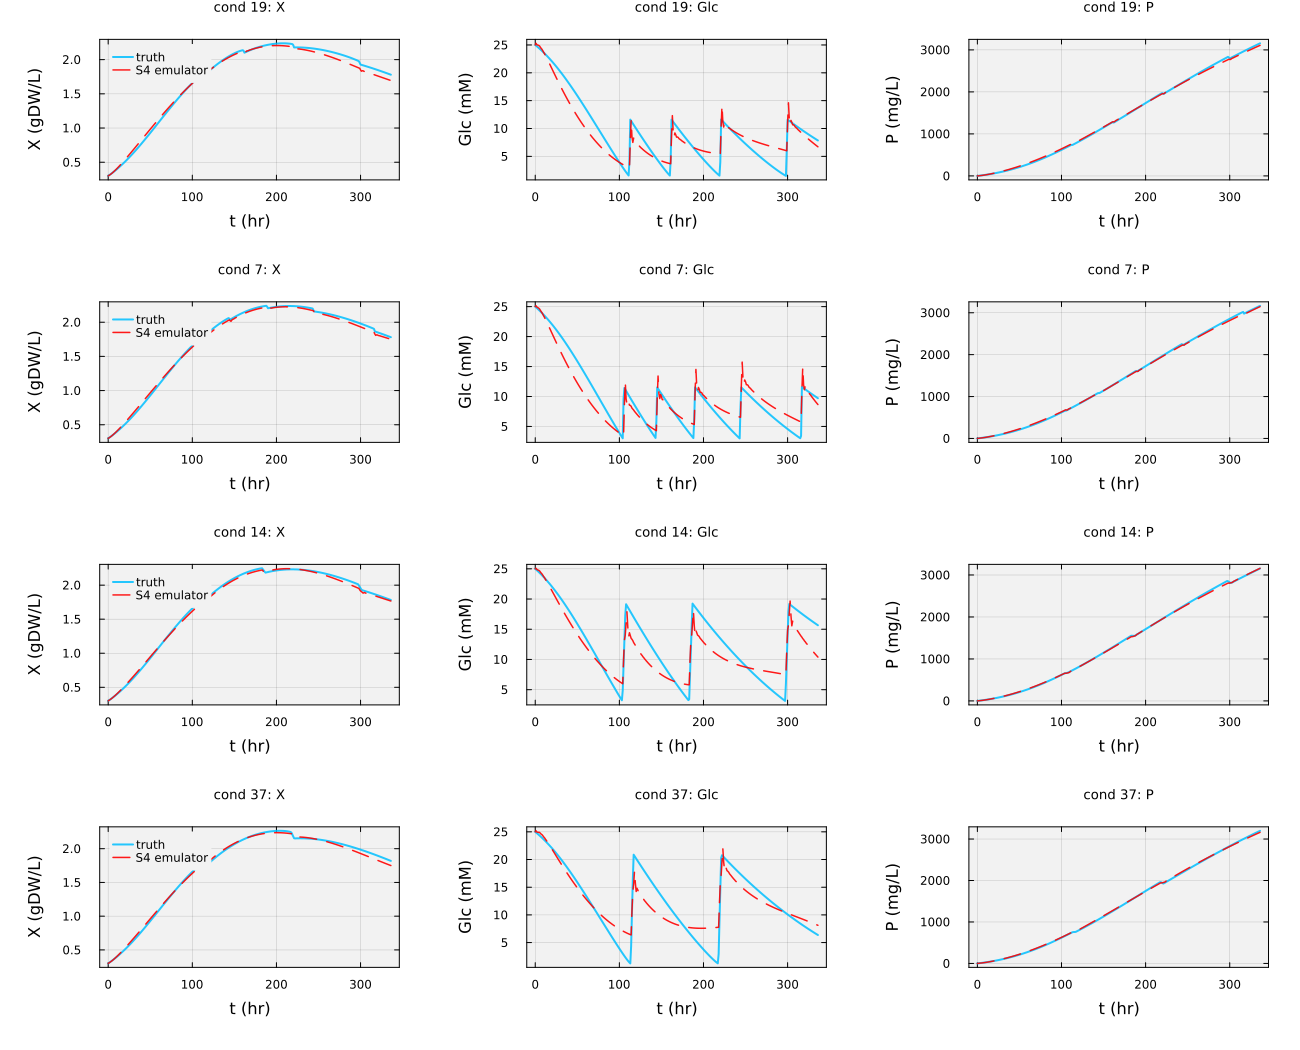

In [8]:
let
    show_conds   = test_idx[1:4]
    show_states  = [2, 3, 5]                      # X, Glc, P (dropped Lac: shown in Task 2)
    state_labels = ["V", "X", "Glc", "Gln", "P", "Lac", "Amm"]
    state_units  = ["L", "gDW/L", "mM", "mM", "mg/L", "mM", "mM"]

    plots_grid = Any[]
    for i in show_conds
        # noisy x0, clean glucose for fon, clean trajectory for ground-truth overlay
        x0      = state_norm[i][1, :]
        fon     = compute_feed_on(state_arrays_true[i][:, GLC_IDX])
        preds   = autoregressive_rollout_feedon(ssm, x0, cond_norm[i], fon)
        preds_d = denormalize_minmax(preds, state_mins, state_maxs)
        truth_d = state_arrays_true[i]
        for (k, s) in enumerate(show_states)
            p = plot(time_vector, truth_d[:, s];
                     label = k == 1 ? "truth"       : "",
                     lw = 2, c = :deepskyblue, alpha = 0.85,
                     bg = "gray95", background_color_outside = "white",
                     framestyle = :box, fg_legend = :transparent,
                     xlabel = "t (hr)",
                     ylabel = "$(state_labels[s]) ($(state_units[s]))",
                     title = "cond $(i): $(state_labels[s])", titlefont = font(9))
            plot!(p, time_vector, preds_d[:, s];
                  label = k == 1 ? "S4 emulator" : "",
                  lw = 1.5, c = :red, alpha = 0.9, ls = :dash)
            push!(plots_grid, p)
        end
    end
    plot(plots_grid...; layout = (4, 3), size = (1300, 1050),
         left_margin = 10Plots.mm, bottom_margin = 8Plots.mm,
         right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Feed-rate ablation
Does the 12th channel actually carry its weight? To make the feature-engineering story concrete we refit the readout without the $f_t \cdot F_\text{max}^\text{norm}$ channel (a strict `d_in = 11` ablation), rerun the same autoregressive evaluation on the held-out conditions, and compare per-state test MSE against the `d_in = 12` emulator above.

In [ ]:
ablation = let
    # build and fit the d_in = 11 baseline: everything the main model sees EXCEPT
    # the feed_rate channel
    D_IN_NOFR = N_STATES + N_COND + 1
    m_nofr = build(MyMimoLegSHippoModel; h = H_PER_CHANNEL, d_in = D_IN_NOFR, d_out = D_OUT, Δt = 1.0)
    U_list = Matrix{Float64}[]
    Y_list = Matrix{Float64}[]
    for i in train_idx
        X = state_norm[i]; c = cond_norm[i]
        fon = compute_feed_on(state_arrays_true[i][:, GLC_IDX])       # clean-glucose fon
        T = size(X, 1)
        U = zeros(Float64, T - 1, D_IN_NOFR)
        Y = zeros(Float64, T - 1, D_OUT)
        for t in 1:(T - 1)
            U[t, 1:N_STATES]                         = X[t, :]
            U[t, (N_STATES + 1):(N_STATES + N_COND)] = c
            U[t, N_STATES + N_COND + 1]              = fon[t]
            Y[t, :]                                  = X[t + 1, :]
        end
        push!(U_list, U); push!(Y_list, Y)
    end
    fit_C_multi!(m_nofr, U_list, Y_list; λ = RIDGE_λ)

    # evaluate the d_in = 11 baseline autoregressively (roll the rollout inline
    # since autoregressive_rollout_feedon assumes the 12-channel layout)
    per_state_nofr = zeros(Float64, N_STATES)
    for i in test_idx
        x0  = state_norm[i][1, :]
        fon = compute_feed_on(state_arrays_true[i][:, GLC_IDX])
        T   = length(fon)
        preds = zeros(Float64, T, N_STATES); preds[1, :] = x0
        h_state = copy(m_nofr.x₀); u = zeros(D_IN_NOFR); c_f = collect(cond_norm[i])
        for t in 1:(T - 1)
            for j in 1:N_STATES; u[j] = preds[t, j]; end
            for j in 1:N_COND;  u[N_STATES + j] = c_f[j]; end
            u[N_STATES + N_COND + 1] = fon[t]
            h_state = m_nofr.Ā * h_state + m_nofr.B̄ * u
            y_t = m_nofr.C * h_state .+ m_nofr.D * u
            for j in 1:N_STATES; preds[t + 1, j] = y_t[j]; end
        end
        # Score against the CLEAN normalized trajectory, same convention as Task 3.
        for s in 1:N_STATES
            per_state_nofr[s] += mean((preds[:, s] .- state_norm_true[i][:, s]) .^ 2)
        end
    end
    per_state_nofr ./= length(test_idx)

    # recompute the d_in = 12 per-state MSE for the side-by-side (against clean truth)
    per_state_fr = zeros(Float64, N_STATES)
    for i in test_idx
        x0  = state_norm[i][1, :]
        fon = compute_feed_on(state_arrays_true[i][:, GLC_IDX])
        preds = autoregressive_rollout_feedon(ssm, x0, cond_norm[i], fon)
        for s in 1:N_STATES
            per_state_fr[s] += mean((preds[:, s] .- state_norm_true[i][:, s]) .^ 2)
        end
    end
    per_state_fr ./= length(test_idx)

    state_labels = ["V", "X", "Glc", "Gln", "P", "Lac", "Amm"]
    df = DataFrame(
        state                  = state_labels,
        mse_d_in_11_no_feedrate = round.(per_state_nofr; sigdigits = 4),
        mse_d_in_12_with_feedrate = round.(per_state_fr; sigdigits = 4),
        ratio                  = round.(per_state_nofr ./ max.(per_state_fr, 1.0e-12); sigdigits = 3),
    )
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__simple))
    @info "ablation totals (normalized MSE, mean over test set)" σ_train=TRAIN_NOISE_σ_REL σ_eval=EVAL_NOISE_σ_REL without_feedrate=round(mean(per_state_nofr); digits=5) with_feedrate=round(mean(per_state_fr); digits=5)
    df
end;

### Things to think about
* __What happens when the emulator is fit on clean data but evaluated with noisy sensors?__ Leave `TRAIN_NOISE_σ_REL = 0.0` so the cached model loads without refitting, then sweep `EVAL_NOISE_σ_REL` through `0.02`, `0.05`, and `0.10` and rerun Tasks 1 and 3 for each setting. Track: (a) the per-state MSE table, (b) the 4 × 3 test-condition grid for visible tracking failures, and (c) the final-titer and max-biomass deltas in the summary table. Why does a modest-looking per-sample noise level cause disproportionate damage to the full 14-day forecast relative to the teacher-forced fit? Tie your answer to the feedback loop in [the `autoregressive_rollout_feedon(...)` function](src/Compute.jl): each step's noisy prediction becomes the next step's input, so residuals compound.

___

## In context: comparing to the L12d LSTM
Both labs attack the same forecasting task on the same bioreactor model, differ only in the recurrent architecture and the training recipe, and report the same metrics. The cell below pulls the L14d emulator's test numbers from `test_metrics` above and stacks them next to the L12d LSTM solution notebook's reported numbers so the two are side by side.

In [10]:
let
    # L14d emulator numbers, computed live from the test_metrics DataFrame
    s4_mean   = round(mean(test_metrics.mse_norm); sigdigits = 3)
    s4_median = round(median(test_metrics.mse_norm); sigdigits = 3)
    s4_max    = round(maximum(test_metrics.mse_norm); sigdigits = 3)

    # L12d LSTM numbers, transcribed from the test metrics table in
    # labs/week-12/L12d/CHEME-5820-L12d-Lab-Solution-LSTM-CHO-Spring-2026.ipynb
    lstm_mse = [0.01224, 0.02715, 0.02600, 0.004366, 0.009993,
                0.02009, 0.01026, 0.01133, 0.1997, 0.03136]
    lstm_mean   = round(mean(lstm_mse); sigdigits = 3)
    lstm_median = round(median(lstm_mse); sigdigits = 3)
    lstm_max    = round(maximum(lstm_mse); sigdigits = 3)

    df = DataFrame(
        metric         = ["mean normalized MSE", "median normalized MSE",
                           "max normalized MSE", "trainable parameters",
                           "fit procedure", "training hyperparameters tuned"],
        S4_emulator    = [string(s4_mean), string(s4_median), string(s4_max),
                           "$(D_OUT * H_PER_CHANNEL * D_IN) readout entries (frozen SSM)",
                           "one $(H_PER_CHANNEL * D_IN) × $(H_PER_CHANNEL * D_IN) ridge solve",
                           "λ, h (one each)"],
        L12d_LSTM      = [string(lstm_mean), string(lstm_median), string(lstm_max),
                           "all LSTM gates + dense output head",
                           "500 SGD epochs with teacher forcing",
                           "learning rate, epochs, batch size, hidden dim"],
    )
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__simple))
    @info "headline gap" s4_mean=s4_mean lstm_mean=lstm_mean ratio_lstm_over_s4=round(lstm_mean / s4_mean; digits = 1)
end

================================= ================================== ================================================
                          metric                        S4_emulator                                       L12d_LSTM 
                          String                             String                                          String 
================================= ================================== ================================================
             mean normalized MSE                            0.00379                                          0.0352
           median normalized MSE                            0.00273                                          0.0162
              max normalized MSE                            0.00902                                             0.2
            trainable parameters   672 readout entries (frozen SSM)              all LSTM gates + dense output head
                   fit procedure            one 96 × 96 ridge solv

┌ Info: headline gap
│   s4_mean = 0.00379
│   lstm_mean = 0.0352
│   ratio_lstm_over_s4 = 9.3
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14d/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X33sZmlsZQ==.jl:32


## Summary
This notebook used a MIMO HiPPO-LegS structured state space model as a frozen feature extractor for fed-batch CHO bioreactor forecasting, fitting only the dense readout $\bar{\mathbf{C}}$ by a single closed-form ridge solve across 40 training trajectories at different feed policies. We then rolled the trained emulator autoregressively on 10 held-out feed policies, compared the resulting seven-state trajectories to the ground-truth ODE solution, and reported per-condition and per-state MSE, final antibody titer, and maximum biomass density. The comparison target is the L12d LSTM lab, which solves the same forecasting problem with teacher-forced MSE training over 500 SGD epochs.

> __Key Takeaways:__
>
> * **Frozen dynamics, ridge-fit readout:** The HiPPO-LegS matrices are analytically defined, so the only trained object is the dense readout that maps the SSM hidden state to the next-step state. With the dynamics frozen, the mean-squared next-state loss becomes a closed-form ridge problem that takes one linear solve rather than a training loop.
> * **Engineered feed-rate channel does the real work:** A linear readout cannot multiply two input channels on its own, so we precompute the product of the pump-on indicator and the max feed rate and hand it in as a 12th channel. The ablation shows this one engineered feature cuts total test MSE by roughly half, almost entirely by fixing glucose and glutamine.
> * **Same task, much cheaper fit than the LSTM:** On the same fed-batch problem the emulator reaches lower mean and max normalized test MSE than the L12d LSTM solution. It does so with a single ridge solve in under a second, no SGD epochs, and only two hyperparameters.
> * **Measurement noise compounds through the autoregressive loop:** The `TRAIN_NOISE_σ_REL` and `EVAL_NOISE_σ_REL` knobs set the sensor-noise level on the training and held-out splits independently. Because the model cache is keyed only on the training σ, you can fit once on clean data and sweep the eval σ as an out-of-distribution stress test without refitting. A noise level that looks innocuous at a single time step can still blow up the full 14-day rollout because each step's prediction becomes the next step's input, so residuals accumulate rather than average out. The normalized-MSE and natural-unit metrics stay honest because scoring is done against the clean ODE trajectory rather than the noisy observations the model saw.

A natural follow-up: stack multiple LegS layers with pointwise nonlinearities between them (the move from lecture-grade MIMO S4 to an S4 block in the original paper), or let the ridge target include additional bioreactor diagnostics (cumulative feed consumed, dO₂, pH) so the emulator learns richer process-state relationships.

___